# Exploratory Data Analysis

## 1. Problem Definition

We are solving a **binary classification** problem. Given a set of
financial features for a borrower, we want to predict the probability
that they will experience serious financial distress in the next two years.

Formally, let $\mathbf{x} \in \mathbb{R}^{10}$ be the feature vector
for a borrower. We want to learn a function:

$$f(\mathbf{x}) = P(Y = 1 \mid \mathbf{x})$$

where $Y = 1$ indicates the borrower will be 90+ days past due
on any debt obligation within the next 2 years, and $Y = 0$ indicates
they will not.

### Why ROC-AUC?

Given severe class imbalance, accuracy is misleading. A model that
predicts $\hat{Y} = 0$ for every borrower achieves ~93% accuracy
but is completely useless. ROC-AUC measures discriminative ability
regardless of threshold:

$$\text{AUC} = P(\hat{f}(x^+) > \hat{f}(x^-))$$

where $x^+$ is a randomly chosen defaulter and $x^-$ is a randomly
chosen non-defaulter. A perfect model scores 1.0; random guessing scores 0.5.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot styling
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
df = pd.read_csv("../data/cs-training.csv", index_col=0)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")

Dataset shape: 150,000 rows x 11 columns

Column names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [5]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "missing": df.isnull().sum(),
    "missing_%": (df.isnull().sum() / len(df) * 100).round(2),
    "unique": df.nunique(),
})

print(summary.to_string())

                                        dtype  non_null  missing  missing_%  unique
SeriousDlqin2yrs                        int64    150000        0       0.00       2
RevolvingUtilizationOfUnsecuredLines  float64    150000        0       0.00  125728
age                                     int64    150000        0       0.00      86
NumberOfTime30-59DaysPastDueNotWorse    int64    150000        0       0.00      16
DebtRatio                             float64    150000        0       0.00  114194
MonthlyIncome                         float64    120269    29731      19.82   13594
NumberOfOpenCreditLinesAndLoans         int64    150000        0       0.00      58
NumberOfTimes90DaysLate                 int64    150000        0       0.00      19
NumberRealEstateLoansOrLines            int64    150000        0       0.00      28
NumberOfTime60-89DaysPastDueNotWorse    int64    150000        0       0.00      13
NumberOfDependents                    float64    146076     3924       2.62 

## 2. Missing Values

Two features contain missing values:

- **MonthlyIncome** — 29,731 missing (~19.8%). This is a significant
  proportion and requires careful imputation strategy (addressed in
  the preprocessing notebook).
- **NumberOfDependents** — 3,924 missing (~2.6%). A smaller proportion,
  but still non-trivial.

Dropping these rows would eliminate ~20% of the dataset, which is
unacceptable given the already severe class imbalance. Imputation
is the correct approach here.

In [7]:
df.describe().round(2)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


Class Distribution:
  Non-default (0): 139,974 (93.3%)
  Default     (1): 10,026 (6.7%)

Imbalance ratio: 14.0:1


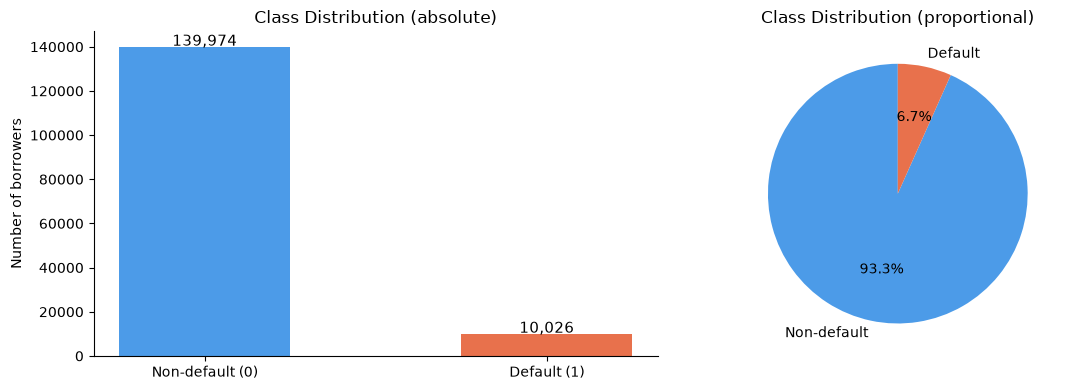

In [8]:
class_counts = df["SeriousDlqin2yrs"].value_counts()
class_pct = df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Non-default (0): {class_counts[0]:,} ({class_pct[0]:.1f}%)")
print(f"  Default     (1): {class_counts[1]:,} ({class_pct[1]:.1f}%)")
print(f"\nImbalance ratio: {class_counts[0] / class_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Non-default (0)", "Default (1)"],
            class_counts.values,
            color=["#4C9BE8", "#E8714C"],
            width=0.5)
axes[0].set_title("Class Distribution (absolute)")
axes[0].set_ylabel("Number of borrowers")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=11)

# Pie chart
axes[1].pie(class_counts.values,
            labels=["Non-default", "Default"],
            autopct="%1.1f%%",
            colors=["#4C9BE8", "#E8714C"],
            startangle=90)
axes[1].set_title("Class Distribution (proportional)")

plt.tight_layout()
plt.savefig("../models/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Class Imbalance Analysis

The dataset exhibits severe class imbalance. We can quantify this
with the **imbalance ratio** $IR$:

$$IR = \frac{N_{\text{majority}}}{N_{\text{minority}}} = \frac{139,974}{10,026} \approx 13.96$$

This means for every borrower who defaults, there are approximately
**14 who do not**. This has critical implications:

- A naive classifier predicting $\hat{Y} = 0$ always achieves **93.3% accuracy**
  but **0% recall** on the minority class — completely useless.
- Standard model training will be biased toward the majority class.
- We must use a resampling strategy (addressed in Notebook 02).
- Evaluation must use **ROC-AUC**, **F1**, and **KS statistic**,
  not accuracy.